In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans

In [3]:
df = pd.read_csv('heart_attack_youngsters_india.csv')

In [4]:
df.shape


(10000, 26)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 26 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Age                                       10000 non-null  int64  
 1   Gender                                    10000 non-null  str    
 2   Region                                    10000 non-null  str    
 3   Urban/Rural                               10000 non-null  str    
 4   SES                                       10000 non-null  str    
 5   Smoking Status                            10000 non-null  str    
 6   Alcohol Consumption                       10000 non-null  str    
 7   Diet Type                                 10000 non-null  str    
 8   Physical Activity Level                   10000 non-null  str    
 9   Screen Time (hrs/day)                     10000 non-null  int64  
 10  Sleep Duration (hrs/day)                  1000

In [6]:
df.describe()

,Age,Screen Time (hrs/day),Sleep Duration (hrs/day),Cholesterol Levels (mg/dL),BMI (kg/m²),Resting Heart Rate (bpm),Maximum Heart Rate Achieved,Blood Oxygen Levels (SpO2%),Triglyceride Levels (mg/dL)
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000
mean,26.601500,7.510700,6.489600,199.649000,27.44190,89.493400,159.683900,94.940730,275.010100
std,5.164239,4.626578,2.289327,57.561902,7.22374,17.318237,35.034037,2.883329,128.825994
min,18.000000,0.000000,3.000000,100.000000,15.00000,60.000000,100.000000,90.000000,50.000000
25%,22.000000,4.000000,4.000000,150.000000,21.20000,74.000000,129.000000,92.400000,164.000000
50%,27.000000,8.000000,6.000000,199.000000,27.50000,90.000000,160.000000,94.900000,277.000000
75%,31.000000,12.000000,8.000000,249.000000,33.70000,104.000000,190.000000,97.400000,385.000000
max,35.000000,15.000000,10.000000,300.000000,40.00000,119.000000,220.000000,100.000000,500.000000


In [7]:
df.isnull().sum()

Age                                         0
Gender                                      0
Region                                      0
Urban/Rural                                 0
SES                                         0
Smoking Status                              0
Alcohol Consumption                         0
Diet Type                                   0
Physical Activity Level                     0
Screen Time (hrs/day)                       0
Sleep Duration (hrs/day)                    0
Family History of Heart Disease             0
Diabetes                                    0
Hypertension                                0
Cholesterol Levels (mg/dL)                  0
BMI (kg/m²)                                 0
Stress Level                                0
Blood Pressure (systolic/diastolic mmHg)    0
Resting Heart Rate (bpm)                    0
ECG Results                                 0
Chest Pain Type                             0
Maximum Heart Rate Achieved       

In [8]:
df = df.dropna()

In [9]:
df.dtypes

Age                                           int64
Gender                                          str
Region                                          str
Urban/Rural                                     str
SES                                             str
Smoking Status                                  str
Alcohol Consumption                             str
Diet Type                                       str
Physical Activity Level                         str
Screen Time (hrs/day)                         int64
Sleep Duration (hrs/day)                      int64
Family History of Heart Disease                 str
Diabetes                                        str
Hypertension                                    str
Cholesterol Levels (mg/dL)                    int64
BMI (kg/m²)                                 float64
Stress Level                                    str
Blood Pressure (systolic/diastolic mmHg)        str
Resting Heart Rate (bpm)                      int64
ECG Results 

In [10]:
numeric_col = df.select_dtypes(include=["float64", "int64"]).columns
categorical_col = df.select_dtypes(include=["object","category","bool"]).columns

numeric_col
categorical_col

C:\Users\chanu\AppData\Local\Temp\ipykernel_5252\4093166038.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_col = df.select_dtypes(include=["object","category","bool"]).columns


Index(['Gender', 'Region', 'Urban/Rural', 'SES', 'Smoking Status',
       'Alcohol Consumption', 'Diet Type', 'Physical Activity Level',
       'Family History of Heart Disease', 'Diabetes', 'Hypertension',
       'Stress Level', 'Blood Pressure (systolic/diastolic mmHg)',
       'ECG Results', 'Chest Pain Type', 'Exercise Induced Angina',
       'Heart Attack Likelihood'],
      dtype='str')

In [11]:
df.isna().sum().sort_values(ascending=False)


Age                                         0
Gender                                      0
Region                                      0
Urban/Rural                                 0
SES                                         0
Smoking Status                              0
Alcohol Consumption                         0
Diet Type                                   0
Physical Activity Level                     0
Screen Time (hrs/day)                       0
Sleep Duration (hrs/day)                    0
Family History of Heart Disease             0
Diabetes                                    0
Hypertension                                0
Cholesterol Levels (mg/dL)                  0
BMI (kg/m²)                                 0
Stress Level                                0
Blood Pressure (systolic/diastolic mmHg)    0
Resting Heart Rate (bpm)                    0
ECG Results                                 0
Chest Pain Type                             0
Maximum Heart Rate Achieved       

In [12]:
(df.isna().mean()*100).sort_values(ascending=False)


Age                                         0.0
Gender                                      0.0
Region                                      0.0
Urban/Rural                                 0.0
SES                                         0.0
Smoking Status                              0.0
Alcohol Consumption                         0.0
Diet Type                                   0.0
Physical Activity Level                     0.0
Screen Time (hrs/day)                       0.0
Sleep Duration (hrs/day)                    0.0
Family History of Heart Disease             0.0
Diabetes                                    0.0
Hypertension                                0.0
Cholesterol Levels (mg/dL)                  0.0
BMI (kg/m²)                                 0.0
Stress Level                                0.0
Blood Pressure (systolic/diastolic mmHg)    0.0
Resting Heart Rate (bpm)                    0.0
ECG Results                                 0.0
Chest Pain Type                         

In [13]:
df_impute = df.copy()

for col in numeric_col:
    df_impute[col] = df_impute[col].fillna(df_impute[col].median())

for col in categorical_col:
    df_impute[col] = df_impute[col].fillna(df_impute[col].mode()[0])

df_impute.isna().sum()


Age                                         0
Gender                                      0
Region                                      0
Urban/Rural                                 0
SES                                         0
Smoking Status                              0
Alcohol Consumption                         0
Diet Type                                   0
Physical Activity Level                     0
Screen Time (hrs/day)                       0
Sleep Duration (hrs/day)                    0
Family History of Heart Disease             0
Diabetes                                    0
Hypertension                                0
Cholesterol Levels (mg/dL)                  0
BMI (kg/m²)                                 0
Stress Level                                0
Blood Pressure (systolic/diastolic mmHg)    0
Resting Heart Rate (bpm)                    0
ECG Results                                 0
Chest Pain Type                             0
Maximum Heart Rate Achieved       

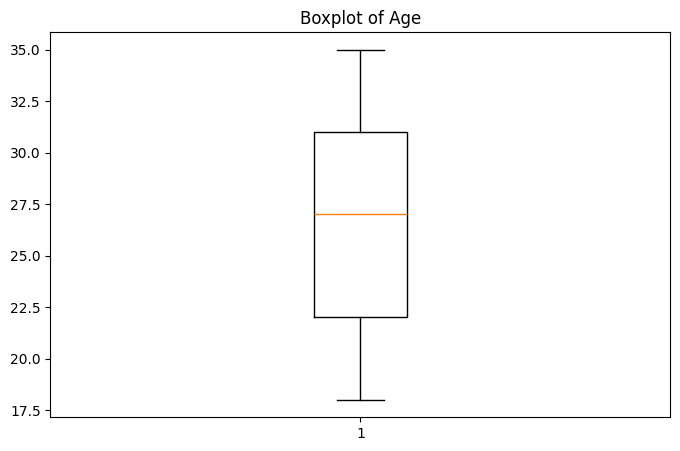

In [14]:
plt.figure(figsize=(8,5))
plt.boxplot(df_impute["Age"])
plt.title("Boxplot of Age")
plt.show()


In [15]:
Q1 = df_impute['Age'].quantile(0.25)
Q3 = df_impute['Age'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_filtered = df_impute[(df_impute['Age'] >= lower_bound) &
                         (df_impute['Age'] <= upper_bound)]

df_filtered.shape


(10000, 26)

In [16]:
df_encoded = pd.get_dummies(df_filtered, columns=categorical_col, dummy_na=False)
df_encoded.head()


,Age,Screen Time (hrs/day),Sleep Duration (hrs/day),Cholesterol Levels (mg/dL),BMI (kg/m²),Resting Heart Rate (bpm),Maximum Heart Rate Achieved,Blood Oxygen Levels (SpO2%),Triglyceride Levels (mg/dL),Gender_Female,...,ECG Results_Abnormal,ECG Results_Normal,Chest Pain Type_Asymptomatic,Chest Pain Type_Atypical,Chest Pain Type_Non-anginal,Chest Pain Type_Typical,Exercise Induced Angina_No,Exercise Induced Angina_Yes,Heart Attack Likelihood_No,Heart Attack Likelihood_Yes
0,30,3,8,148,34.4,82,183,94.1,58,False,...,False,True,False,False,True,False,True,False,True,False
1,24,15,9,124,25.0,76,118,97.1,341,True,...,False,True,False,False,True,False,True,False,True,False
2,24,15,3,256,33.9,86,164,92.7,373,True,...,False,True,False,False,False,True,True,False,False,True
3,27,6,7,137,19.0,106,188,98.4,102,False,...,False,True,False,False,True,False,True,False,False,True
4,21,4,9,262,28.0,73,216,94.9,235,True,...,False,True,False,True,False,False,True,False,True,False


In [17]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(df_encoded)

df_scaled = pd.DataFrame(scaled_data, columns=df_encoded.columns)

df_scaled.head()


,Age,Screen Time (hrs/day),Sleep Duration (hrs/day),Cholesterol Levels (mg/dL),BMI (kg/m²),Resting Heart Rate (bpm),Maximum Heart Rate Achieved,Blood Oxygen Levels (SpO2%),Triglyceride Levels (mg/dL),Gender_Female,...,ECG Results_Abnormal,ECG Results_Normal,Chest Pain Type_Asymptomatic,Chest Pain Type_Atypical,Chest Pain Type_Non-anginal,Chest Pain Type_Typical,Exercise Induced Angina_No,Exercise Induced Angina_Yes,Heart Attack Likelihood_No,Heart Attack Likelihood_Yes
0,0.658116,-0.975003,0.659790,-0.897322,0.963275,-0.432710,0.665560,-0.291598,-1.684605,-0.971603,...,-0.417445,0.417445,-0.575349,-0.571192,1.728364,-0.584279,0.331293,-0.331293,0.505931,-0.505931
1,-0.503778,1.618837,1.096622,-1.314286,-0.338055,-0.779183,-1.189871,0.748918,0.512266,1.029227,...,-0.417445,0.417445,-0.575349,-0.571192,1.728364,-0.584279,0.331293,-0.331293,0.505931,-0.505931
2,-0.503778,1.618837,-1.524367,0.979012,0.894055,-0.201728,0.123203,-0.777172,0.760676,1.029227,...,-0.417445,0.417445,-0.575349,-0.571192,-0.578582,1.711512,0.331293,-0.331293,-1.976555,1.976555
3,0.077169,-0.326543,0.222959,-1.088431,-1.168691,0.953182,0.808286,1.199809,-1.343042,-0.971603,...,-0.417445,0.417445,-0.575349,-0.571192,1.728364,-0.584279,0.331293,-0.331293,-1.976555,1.976555
4,-1.084725,-0.758849,1.096622,1.083253,0.077263,-0.952419,1.607549,-0.014127,-0.310590,1.029227,...,-0.417445,0.417445,-0.575349,1.750726,-0.578582,-0.584279,0.331293,-0.331293,0.505931,-0.505931


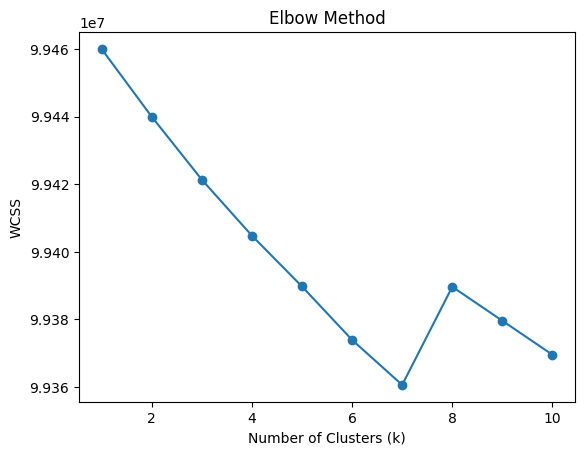

In [18]:
wcss = []

for k in range(1,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS")
plt.show()


In [19]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(df_scaled)

df_scaled["Cluster"] = clusters
df_scaled.head()


,Age,Screen Time (hrs/day),Sleep Duration (hrs/day),Cholesterol Levels (mg/dL),BMI (kg/m²),Resting Heart Rate (bpm),Maximum Heart Rate Achieved,Blood Oxygen Levels (SpO2%),Triglyceride Levels (mg/dL),Gender_Female,...,ECG Results_Normal,Chest Pain Type_Asymptomatic,Chest Pain Type_Atypical,Chest Pain Type_Non-anginal,Chest Pain Type_Typical,Exercise Induced Angina_No,Exercise Induced Angina_Yes,Heart Attack Likelihood_No,Heart Attack Likelihood_Yes,Cluster
0,0.658116,-0.975003,0.659790,-0.897322,0.963275,-0.432710,0.665560,-0.291598,-1.684605,-0.971603,...,0.417445,-0.575349,-0.571192,1.728364,-0.584279,0.331293,-0.331293,0.505931,-0.505931,2
1,-0.503778,1.618837,1.096622,-1.314286,-0.338055,-0.779183,-1.189871,0.748918,0.512266,1.029227,...,0.417445,-0.575349,-0.571192,1.728364,-0.584279,0.331293,-0.331293,0.505931,-0.505931,0
2,-0.503778,1.618837,-1.524367,0.979012,0.894055,-0.201728,0.123203,-0.777172,0.760676,1.029227,...,0.417445,-0.575349,-0.571192,-0.578582,1.711512,0.331293,-0.331293,-1.976555,1.976555,0
3,0.077169,-0.326543,0.222959,-1.088431,-1.168691,0.953182,0.808286,1.199809,-1.343042,-0.971603,...,0.417445,-0.575349,-0.571192,1.728364,-0.584279,0.331293,-0.331293,-1.976555,1.976555,0
4,-1.084725,-0.758849,1.096622,1.083253,0.077263,-0.952419,1.607549,-0.014127,-0.310590,1.029227,...,0.417445,-0.575349,1.750726,-0.578582,-0.584279,0.331293,-0.331293,0.505931,-0.505931,0


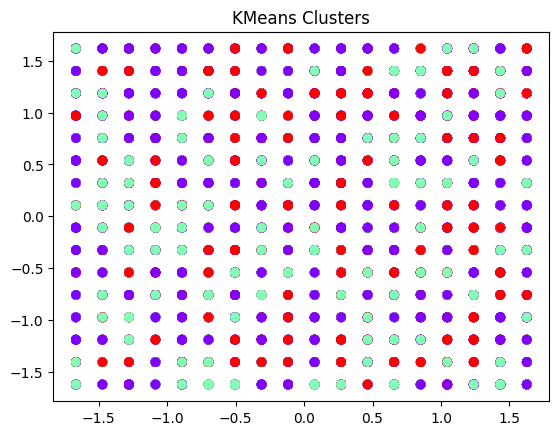

In [20]:
plt.scatter(
    df_scaled.iloc[:,0],
    df_scaled.iloc[:,1],
    c=clusters,
    cmap="rainbow"
)

plt.title("KMeans Clusters")
plt.show()
